# Decision Tree Machine Learning for Credit Risk Analysis

This notebook is based on your FYP project direction:

- Use the corporate rating dataset.
- Build a Decision Tree model.
- Train and test the model.
- Tune hyperparameters.
- Explain which financial ratios affect the prediction.
- Prepare results that you are able to explain during presentation.

The target used in this notebook is `RatingGroup`, not the raw `Rating`.

Why:
- Raw ratings such as `AAA`, `AA`, `A`, `BBB`, `BB`, `B`, `CCC`, `CC`, `C`, `D` have heavy class imbalance.
- Some ratings have too few records, for example `D` has only 1 record.
- Grouping makes the model fairer and easier to explain.
- It also matches the credit risk idea better because the model predicts a risk category, not only a rating label.


## 1. Install and import libraries

Run the install cell only if your Jupyter environment says a package is missing.

Main libraries:
- `pandas` reads and handles the dataset.
- `scikit-learn` builds the Decision Tree model.
- `matplotlib` shows graphs.
- `seaborn` shows clearer heatmaps.
- `joblib` saves the trained model for later website integration.


In [6]:
# Run this only if the imports below fail.
# In VS Code terminal, you may also run:
# pip install pandas scikit-learn matplotlib seaborn joblib shap

# !pip install pandas scikit-learn matplotlib seaborn joblib shap

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

## 2. Load the dataset

Put this notebook in the same folder as `set A corporate_rating.csv`.

If you are using the file inside ChatGPT sandbox, the second path is used automatically.


In [8]:
DATA_PATH = "set A corporate_rating.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = r"C:\Users\24042626\Downloads\DFT Y3 (1)\C300 FYP\Docs\set A corporate_rating.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2029, 31)


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


## 3. Understand the data

This step is similar to what you do in KNIME before training.

Check:
- Number of rows and columns.
- Column names.
- Data types.
- Missing values.
- Rating distribution.

This helps you explain the dataset before the model result.


In [9]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nOriginal rating distribution:")
display(df["Rating"].value_counts())

Rows and columns: (2029, 31)

Column names:
['Rating', 'Name', 'Symbol', 'Rating Agency Name', 'Date', 'Sector', 'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']

Data types:


Rating                                 object
Name                                   object
Symbol                                 object
Rating Agency Name                     object
Date                                   object
Sector                                 object
currentRatio                          float64
quickRatio                            float64
cashRatio                             float64
daysOfSalesOutstanding                float64
netProfitMargin                       float64
pretaxProfitMargin                    float64
grossProfitMargin                     float64
operatingProfitMargin                 float64
returnOnAssets                        float64
returnOnCapitalEmployed               float64
returnOnEquity                        float64
assetTurnover                         float64
fixedAssetTurnover                    float64
debtEquityRatio                       float64
debtRatio                             float64
effectiveTaxRate                  


Missing values:


Rating                                0
Name                                  0
Symbol                                0
Rating Agency Name                    0
Date                                  0
Sector                                0
currentRatio                          0
quickRatio                            0
cashRatio                             0
daysOfSalesOutstanding                0
netProfitMargin                       0
pretaxProfitMargin                    0
grossProfitMargin                     0
operatingProfitMargin                 0
returnOnAssets                        0
returnOnCapitalEmployed               0
returnOnEquity                        0
assetTurnover                         0
fixedAssetTurnover                    0
debtEquityRatio                       0
debtRatio                             0
effectiveTaxRate                      0
freeCashFlowOperatingCashFlowRatio    0
freeCashFlowPerShare                  0
cashPerShare                          0



Original rating distribution:


Rating
BBB    671
BB     490
A      398
B      302
AA      89
CCC     64
AAA      7
CC       5
C        2
D        1
Name: count, dtype: int64

## 4. Create a grouped target column

The original `Rating` column has too many small classes.

For a Decision Tree, this creates a problem:
- The model has too little data for rare ratings.
- The model may memorise rare labels instead of learning real patterns.
- Evaluation becomes unstable.

So we group the ratings into 4 credit risk groups.

Grouping used:
- `AAA`, `AA`, `A` = `Investment-High`
- `BBB` = `Investment-Low`
- `BB`, `B` = `Speculative`
- `CCC`, `CC`, `C`, `D` = `High-Risk`


Grouped rating distribution:


RatingGroup
Speculative        792
Investment-Low     671
Investment-High    494
High-Risk           72
Name: count, dtype: int64

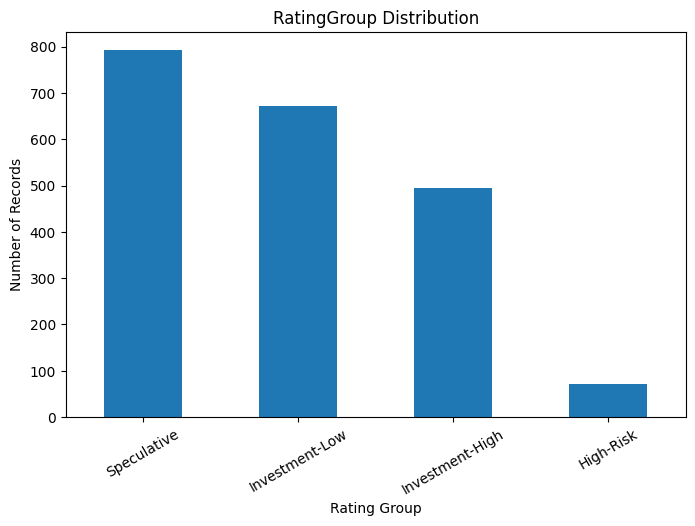

In [10]:
def group_rating(rating):
    if rating in ["AAA", "AA", "A"]:
        return "Investment-High"
    elif rating == "BBB":
        return "Investment-Low"
    elif rating in ["BB", "B"]:
        return "Speculative"
    elif rating in ["CCC", "CC", "C", "D"]:
        return "High-Risk"
    else:
        return "Unknown"

df["RatingGroup"] = df["Rating"].apply(group_rating)

print("Grouped rating distribution:")
display(df["RatingGroup"].value_counts())

plt.figure(figsize=(8, 5))
df["RatingGroup"].value_counts().plot(kind="bar")
plt.title("RatingGroup Distribution")
plt.xlabel("Rating Group")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)
plt.show()

## 5. Choose features and target

Target:
- `RatingGroup`

Features:
- Financial ratio columns.
- `Sector` is included because industry context affects credit risk.

Columns removed:
- `Rating`, because it is the answer before grouping.
- `RatingGroup`, because it is the target.
- `Name`, `Symbol`, `Rating Agency Name`, `Date`, because these are identifiers or metadata.
- Keeping identifiers may cause the model to memorise companies instead of learning financial risk.


In [11]:
target_col = "RatingGroup"

drop_cols = [
    "Rating",
    "RatingGroup",
    "Name",
    "Symbol",
    "Rating Agency Name",
    "Date"
]

X = df.drop(columns=drop_cols)
y = df[target_col]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Target column:", target_col)
print("\nNumeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

display(X.head())
display(y.head())

Target column: RatingGroup

Numeric features: ['currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']

Categorical features: ['Sector']


,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,Consumer Durables,0.945894,0.426395,0.099690,44.203245,0.037480,0.049351,0.176631,0.061510,0.041189,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,Consumer Durables,1.033559,0.498234,0.203120,38.991156,0.044062,0.048857,0.175715,0.066546,0.053204,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,Consumer Durables,0.963703,0.451505,0.122099,50.841385,0.032709,0.044334,0.170843,0.059783,0.032497,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,Consumer Durables,1.019851,0.510402,0.176116,41.161738,0.020894,-0.012858,0.138059,0.042430,0.025690,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,Consumer Durables,0.957844,0.495432,0.141608,47.761126,0.042861,0.053770,0.177720,0.065354,0.046363,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


0    Investment-High
1     Investment-Low
2     Investment-Low
3     Investment-Low
4     Investment-Low
Name: RatingGroup, dtype: object

## 6. Split into training and testing data

The model learns from the training set.

The test set is kept unseen until evaluation.

We use `stratify=y` so each rating group keeps a similar percentage in both training and testing data.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("\nTraining target distribution:")
display(y_train.value_counts())

print("\nTesting target distribution:")
display(y_test.value_counts())

Training rows: 1623
Testing rows: 406

Training target distribution:


RatingGroup
Speculative        633
Investment-Low     537
Investment-High    395
High-Risk           58
Name: count, dtype: int64


Testing target distribution:


RatingGroup
Speculative        159
Investment-Low     134
Investment-High     99
High-Risk           14
Name: count, dtype: int64

## 7. Build the preprocessing and Decision Tree pipeline

This section is similar to your KNIME workflow.

Equivalent idea:
- Missing Value node = `SimpleImputer`
- Category to Number node = `OneHotEncoder`
- Decision Tree Learner node = `DecisionTreeClassifier`
- Decision Tree Predictor node = `.predict()`
- Scorer node = accuracy, confusion matrix, precision, recall, F1-score

A pipeline keeps preprocessing and model training together.


In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 8. Train the baseline Decision Tree model

Baseline means the first version before tuning.

This gives you a starting score.


In [14]:
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred, average="weighted")

print("Baseline Accuracy:", round(baseline_accuracy, 4))
print("Baseline Weighted F1-score:", round(baseline_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, baseline_pred))

Baseline Accuracy: 0.5517
Baseline Weighted F1-score: 0.5492

Classification Report:
                 precision    recall  f1-score   support

      High-Risk       0.07      0.07      0.07        14
Investment-High       0.56      0.57      0.56        99
 Investment-Low       0.50      0.46      0.48       134
    Speculative       0.62      0.67      0.64       159

       accuracy                           0.55       406
      macro avg       0.44      0.44      0.44       406
   weighted avg       0.55      0.55      0.55       406



## 9. Confusion matrix

Rows are the actual classes.

Columns are the predicted classes.

The diagonal cells show correct predictions.

Example:
- If row is `Investment-Low` and column is `Investment-Low`, the model predicted correctly.
- If row is `Investment-Low` and column is `Speculative`, the model confused the two classes.


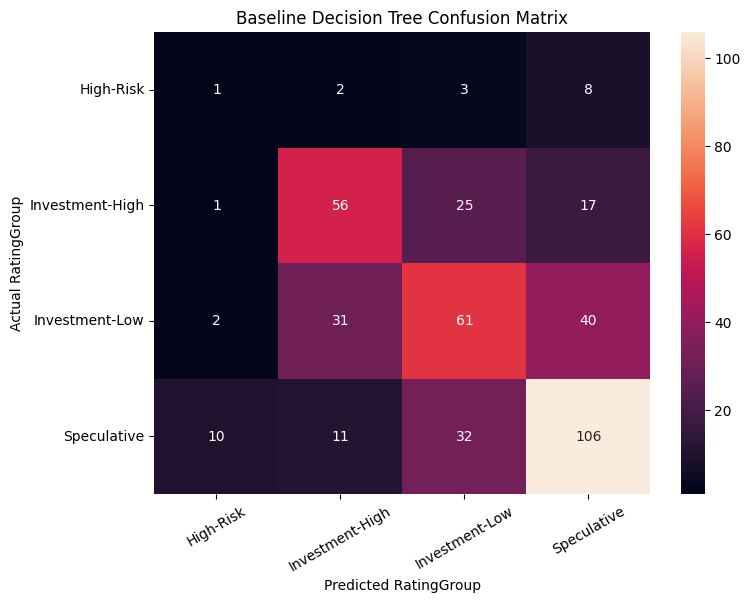

In [15]:
labels = baseline_model.classes_
cm = confusion_matrix(y_test, baseline_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.title("Baseline Decision Tree Confusion Matrix")
plt.xlabel("Predicted RatingGroup")
plt.ylabel("Actual RatingGroup")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.show()

## 10. Tune the Decision Tree hyperparameters

Hyperparameter tuning means testing different model settings to find a better model.

Important settings:
- `criterion`: how the tree decides the best split.
- `max_depth`: maximum depth of the tree.
- `min_samples_leaf`: minimum records needed in a final leaf.
- `class_weight`: gives more attention to smaller classes if set to `balanced`.

For school explanation:
- A deeper tree learns more detail but might overfit.
- A shallower tree is easier to explain but might miss patterns.
- `min_samples_leaf` helps reduce overfitting.


In [16]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 8, 10],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation weighted F1-score:")
print(round(grid_search.best_score_, 4))

Best parameters:
{'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': 8, 'model__min_samples_leaf': 5}

Best cross-validation weighted F1-score:
0.5306


## 11. Evaluate the tuned model

Compare this result against the baseline result.

Use both accuracy and F1-score.

Accuracy alone is not enough when the dataset has class imbalance.


In [17]:
best_model = grid_search.best_estimator_

tuned_pred = best_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred, average="weighted")

print("Baseline Accuracy:", round(baseline_accuracy, 4))
print("Baseline Weighted F1-score:", round(baseline_f1, 4))

print("\nTuned Accuracy:", round(tuned_accuracy, 4))
print("Tuned Weighted F1-score:", round(tuned_f1, 4))

print("\nTuned Classification Report:")
print(classification_report(y_test, tuned_pred))

Baseline Accuracy: 0.5517
Baseline Weighted F1-score: 0.5492

Tuned Accuracy: 0.5616
Tuned Weighted F1-score: 0.5599

Tuned Classification Report:
                 precision    recall  f1-score   support

      High-Risk       0.17      0.14      0.15        14
Investment-High       0.58      0.42      0.49        99
 Investment-Low       0.48      0.60      0.54       134
    Speculative       0.67      0.65      0.66       159

       accuracy                           0.56       406
      macro avg       0.48      0.45      0.46       406
   weighted avg       0.57      0.56      0.56       406



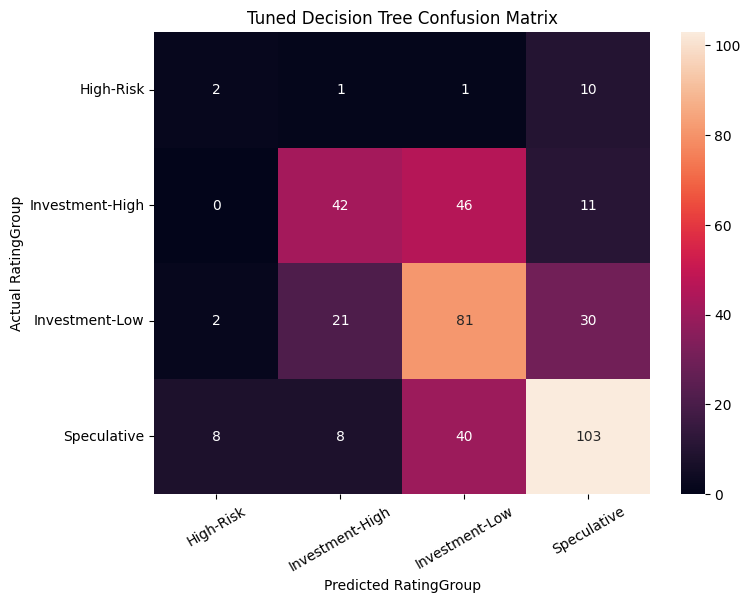

In [18]:
labels = best_model.classes_
cm = confusion_matrix(y_test, tuned_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.title("Tuned Decision Tree Confusion Matrix")
plt.xlabel("Predicted RatingGroup")
plt.ylabel("Actual RatingGroup")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.show()

## 12. Show the Decision Tree

This is useful for presentation because Decision Trees are easier to explain than many other models.

Limit the plot depth so it stays readable.


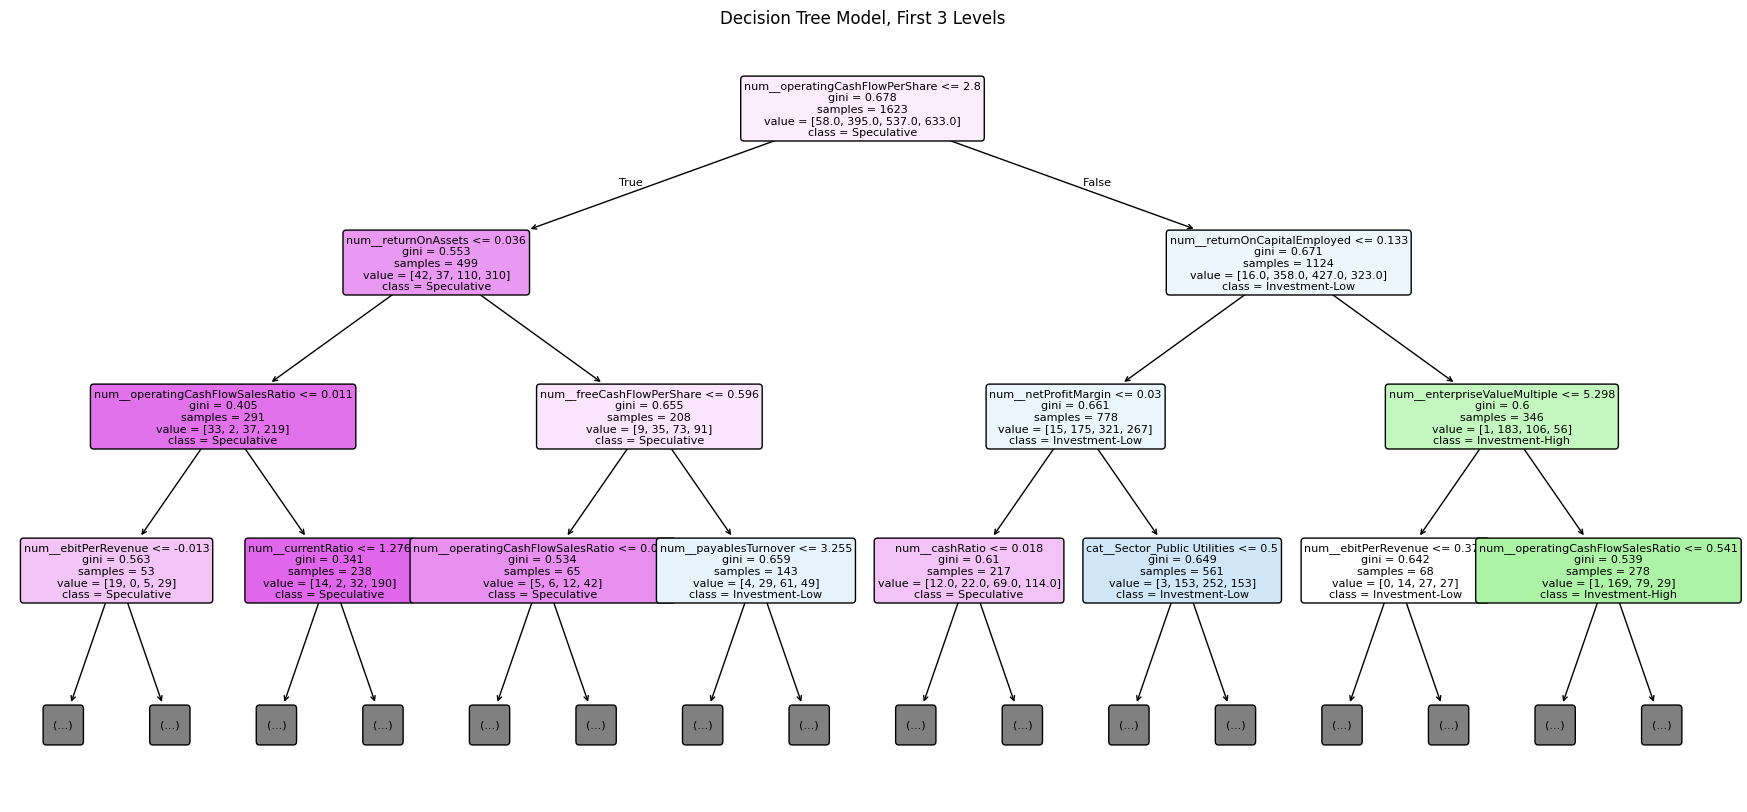

In [19]:
trained_tree = best_model.named_steps["model"]

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(
    trained_tree,
    feature_names=feature_names,
    class_names=best_model.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Model, First 3 Levels")
plt.show()

## 13. Export tree rules as text

Use this when you need to explain model logic in words.

Example explanation:
- The tree checks a financial ratio.
- It compares the ratio against a threshold.
- It moves left or right based on the result.
- The final leaf gives the predicted rating group.


In [20]:
tree_rules = export_text(
    trained_tree,
    feature_names=list(feature_names),
    max_depth=4
)

print(tree_rules[:5000])

|--- num__operatingCashFlowPerShare <= 2.80
|   |--- num__returnOnAssets <= 0.04
|   |   |--- num__operatingCashFlowSalesRatio <= 0.01
|   |   |   |--- num__ebitPerRevenue <= -0.01
|   |   |   |   |--- num__assetTurnover <= 0.25
|   |   |   |   |   |--- class: High-Risk
|   |   |   |   |--- num__assetTurnover >  0.25
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- num__ebitPerRevenue >  -0.01
|   |   |   |   |--- num__operatingProfitMargin <= 0.01
|   |   |   |   |   |--- class: Speculative
|   |   |   |   |--- num__operatingProfitMargin >  0.01
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |--- num__operatingCashFlowSalesRatio >  0.01
|   |   |   |--- num__currentRatio <= 1.28
|   |   |   |   |--- num__currentRatio <= 1.23
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |--- num__currentRatio >  1.23
|   |   |   |   |   |--- class: Investment-Low
|   |   |   |--- num__currentRatio >  1.28
|   |   |   |   |--- num__netProfitMarg

## 14. Feature importance

Feature importance shows which columns the Decision Tree used most when making decisions.

This helps answer:
- Which financial ratios matter more?
- Why are these features important?
- Which areas affect credit risk?


,Feature,Importance
22,num__operatingCashFlowPerShare,0.154808
8,num__returnOnAssets,0.080959
21,num__enterpriseValueMultiple,0.069471
9,num__returnOnCapitalEmployed,0.067910
23,num__operatingCashFlowSalesRatio,0.057633
16,num__freeCashFlowOperatingCashFlowRatio,0.054897
0,num__currentRatio,0.050830
1,num__quickRatio,0.049957
4,num__netProfitMargin,0.043129
12,num__fixedAssetTurnover,0.042428


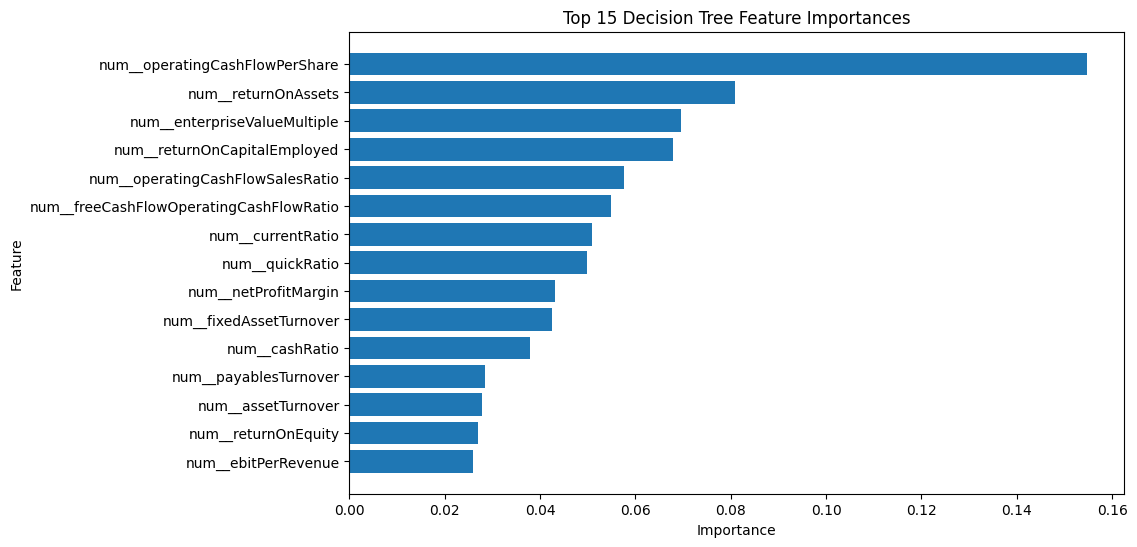

In [21]:
importances = trained_tree.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top_features = feature_importance_df.head(15)

display(top_features)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.title("Top 15 Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 15. Permutation importance

Normal tree importance is useful, but it may favour features used higher in the tree.

Permutation importance checks how much the score drops when one feature is shuffled.

This gives another explanation angle for XAI.


,Feature,Importance Mean,Importance Std
23,operatingCashFlowPerShare,0.102178,0.018697
10,returnOnCapitalEmployed,0.059873,0.015614
0,Sector,0.040269,0.004743
5,netProfitMargin,0.028912,0.011921
24,operatingCashFlowSalesRatio,0.021618,0.005110
13,fixedAssetTurnover,0.020624,0.005858
9,returnOnAssets,0.020105,0.010349
17,freeCashFlowOperatingCashFlowRatio,0.019138,0.009141
15,debtRatio,0.016375,0.002950
1,currentRatio,0.014376,0.011448


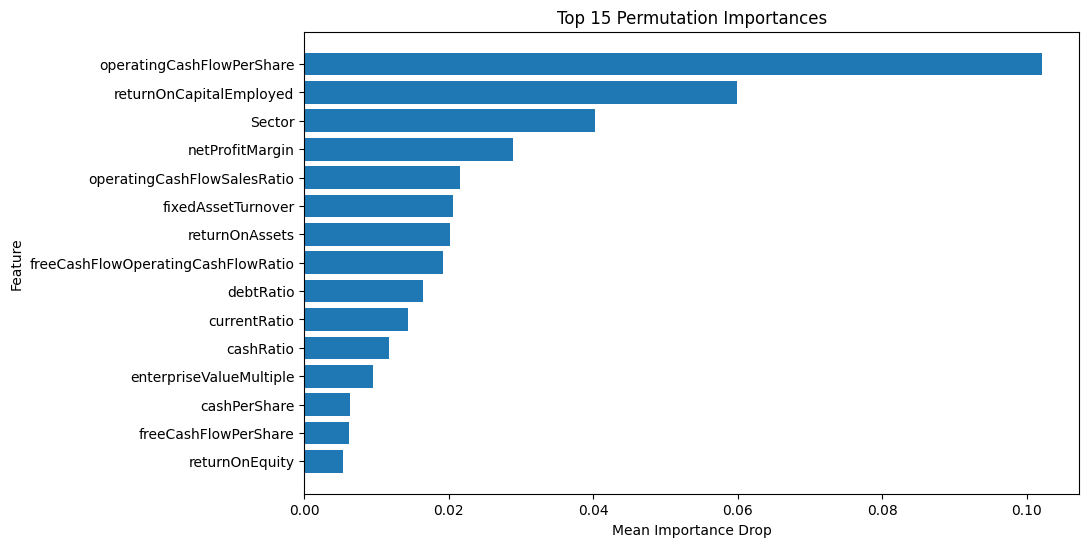

In [22]:
perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1_weighted"
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm_result.importances_mean,
    "Importance Std": perm_result.importances_std
}).sort_values(by="Importance Mean", ascending=False)

display(perm_df.head(15))

plt.figure(figsize=(10, 6))
top_perm = perm_df.head(15)
plt.barh(top_perm["Feature"][::-1], top_perm["Importance Mean"][::-1])
plt.title("Top 15 Permutation Importances")
plt.xlabel("Mean Importance Drop")
plt.ylabel("Feature")
plt.show()

## 16. Predict credit risk for one company record

This section simulates how the model would work in a web application.

A company submits financial ratios.

The model predicts a credit risk group.


In [23]:
sample_company = X_test.iloc[[0]].copy()

print("Sample company input:")
display(sample_company)

prediction = best_model.predict(sample_company)[0]
prediction_proba = best_model.predict_proba(sample_company)[0]

print("Predicted RatingGroup:", prediction)

proba_df = pd.DataFrame({
    "RatingGroup": best_model.classes_,
    "Probability": prediction_proba
}).sort_values(by="Probability", ascending=False)

display(proba_df)

Sample company input:


,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
1462,Consumer Services,0.190268,-0.027959,0.012857,51.237515,0.462053,0.403825,0.944342,0.403825,0.046127,...,0.002835,0.354234,1.696653,-1.176769,2.033529,0.403825,21.402082,4.789638,0.661398,0.254215


Predicted RatingGroup: Speculative


,RatingGroup,Probability
3,Speculative,1.0
0,High-Risk,0.0
1,Investment-High,0.0
2,Investment-Low,0.0


## 17. Explain the Decision Tree using SHAP

SHAP is an XAI method.

It explains how each feature pushes the model toward or away from a predicted class.

For this notebook:
- The model is a Decision Tree.
- The data has preprocessing before training.
- So SHAP must explain the processed feature table, not the raw table.
- Numeric columns stay as numeric columns.
- Categorical columns such as `Sector` become one-hot encoded columns.

In [24]:
# Run this only if SHAP is missing.
# !pip install shap

try:
    import shap
    print("SHAP version:", shap.__version__)
except ImportError as e:
    raise ImportError(
        "SHAP is not installed. Run this in a notebook cell first: !pip install shap"
    ) from e

SHAP version: 0.52.0


### 17.1 Prepare processed data for SHAP

Your model uses a pipeline.

The pipeline has two main parts:
- `preprocessor`: handles missing values and one-hot encoding.
- `model`: the trained Decision Tree.

SHAP explains the trained tree after preprocessing.

In [25]:
# Take the trained parts out of the pipeline.
preprocessor = best_model.named_steps["preprocessor"]
tree_model = best_model.named_steps["model"]

# Transform train and test data exactly the same way the model sees them.
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense table if needed.
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

# Get readable processed feature names.
raw_feature_names = preprocessor.get_feature_names_out()

def clean_feature_name(name):
    return (
        name
        .replace("num__", "")
        .replace("cat__", "")
    )

shap_feature_names = [clean_feature_name(name) for name in raw_feature_names]

X_train_shap = pd.DataFrame(
    X_train_processed,
    columns=shap_feature_names,
    index=X_train.index
)

X_test_shap = pd.DataFrame(
    X_test_processed,
    columns=shap_feature_names,
    index=X_test.index
)

print("Processed training shape:", X_train_shap.shape)
print("Processed testing shape:", X_test_shap.shape)

display(X_test_shap.head())

Processed training shape: (1623, 37)
Processed testing shape: (406, 37)


,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,...,Sector_Consumer Durables,Sector_Consumer Non-Durables,Sector_Consumer Services,Sector_Energy,Sector_Finance,Sector_Health Care,Sector_Miscellaneous,Sector_Public Utilities,Sector_Technology,Sector_Transportation
1462,0.190268,-0.027959,0.012857,51.237515,0.462053,0.403825,0.944342,0.403825,0.046127,0.043772,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
345,0.686786,0.431952,0.000000,102.654065,0.140124,0.027281,0.313666,0.050683,0.035068,0.016597,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
509,1.847625,1.378068,0.633591,116.505172,0.150916,0.228806,0.705892,0.272282,0.066201,0.138289,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
500,1.426435,0.972260,0.264471,70.563473,0.072909,0.136197,1.000000,0.176428,0.033462,0.071520,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
692,1.672330,1.254200,0.632901,51.544760,0.015154,0.021635,0.153580,0.055332,0.013823,0.025164,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 17.2 Create the SHAP explainer

For a Decision Tree, use `TreeExplainer`.

Because this is a multi-class model, SHAP gives one explanation per class.

In [26]:
explainer = shap.TreeExplainer(tree_model)

shap_values = explainer.shap_values(
    X_test_shap,
    check_additivity=False
)

def get_class_shap_values(all_shap_values, class_index):
    """Return SHAP values for one class across all test rows."""
    if isinstance(all_shap_values, list):
        return all_shap_values[class_index]

    all_shap_values = np.array(all_shap_values)

    if all_shap_values.ndim == 3:
        # Common shape: rows, features, classes
        return all_shap_values[:, :, class_index]

    return all_shap_values

print("Model classes:")
print(list(best_model.classes_))

print("\nSHAP output type:", type(shap_values))
if isinstance(shap_values, list):
    print("Number of SHAP class outputs:", len(shap_values))
    print("One class SHAP shape:", shap_values[0].shape)
else:
    print("SHAP array shape:", np.array(shap_values).shape)

Model classes:
['High-Risk', 'Investment-High', 'Investment-Low', 'Speculative']

SHAP output type: <class 'numpy.ndarray'>
SHAP array shape: (406, 37, 4)


### 17.3 Global SHAP importance

This shows the strongest features for each predicted class.

Use this when your lecturer asks which financial ratios affect credit risk most.

,Class,Feature,MeanAbsSHAP
133,Speculative,operatingCashFlowPerShare,0.124308
46,Investment-High,returnOnCapitalEmployed,0.089814
59,Investment-High,operatingCashFlowPerShare,0.086585
96,Investment-Low,operatingCashFlowPerShare,0.075842
120,Speculative,returnOnCapitalEmployed,0.061210
119,Speculative,returnOnAssets,0.049587
115,Speculative,netProfitMargin,0.043994
83,Investment-Low,returnOnCapitalEmployed,0.043148
82,Investment-Low,returnOnAssets,0.032622
58,Investment-High,enterpriseValueMultiple,0.031847


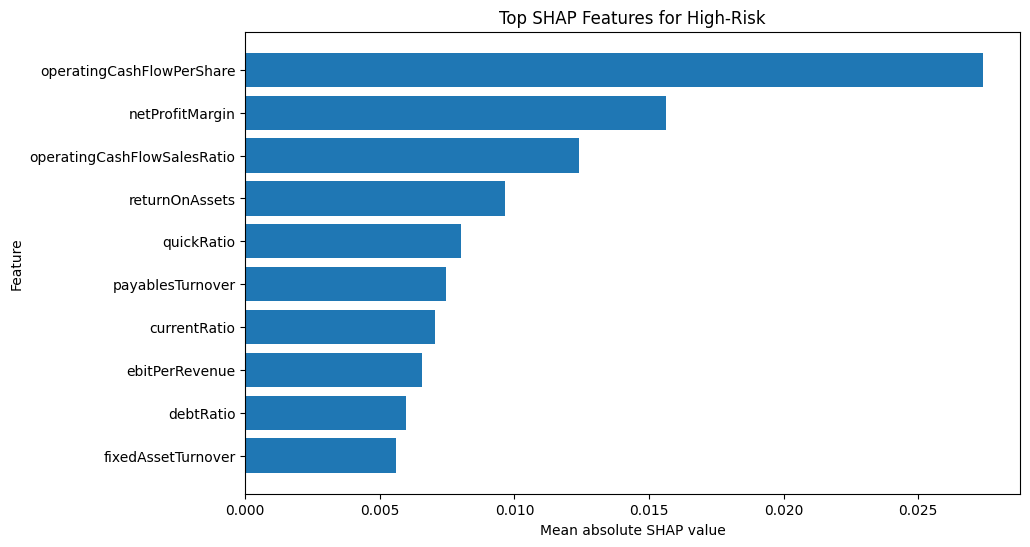

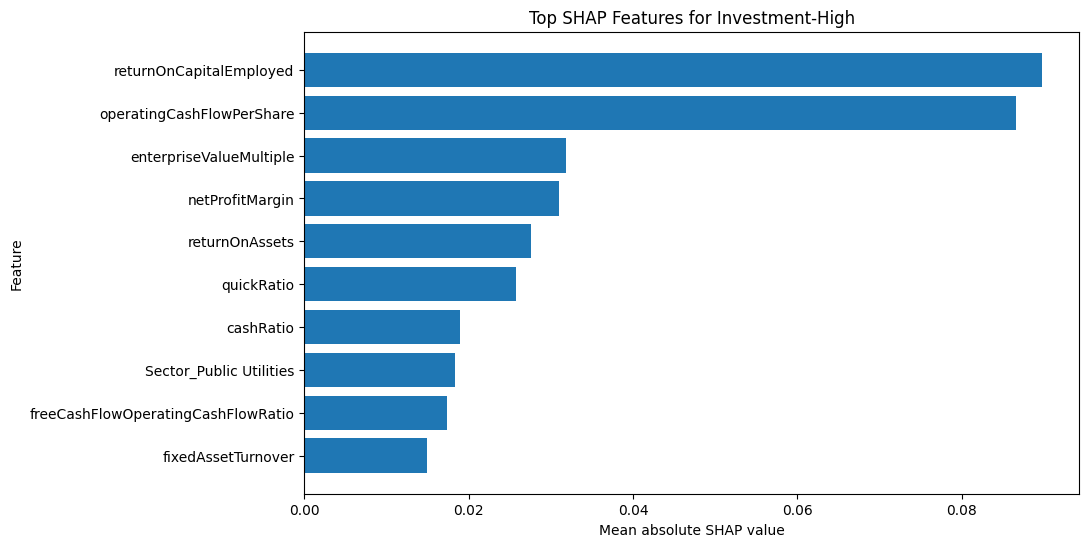

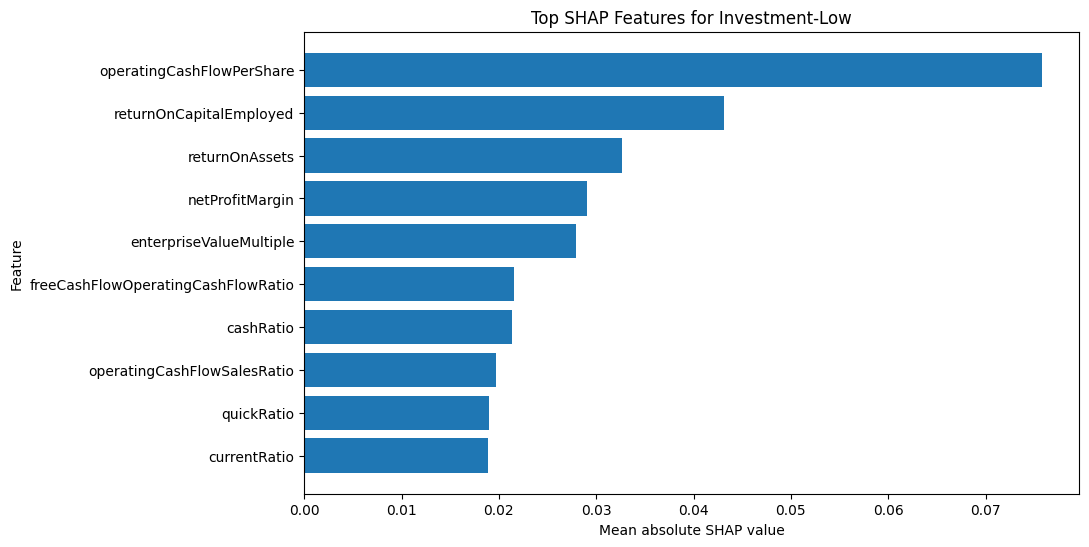

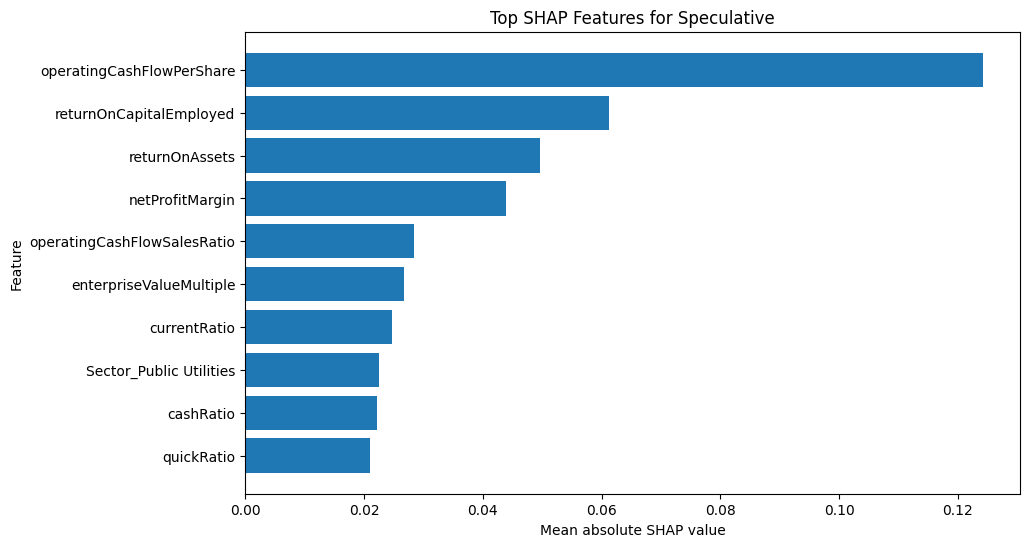

In [27]:
global_shap_rows = []

for class_index, class_name in enumerate(best_model.classes_):
    class_values = get_class_shap_values(shap_values, class_index)

    class_importance = pd.DataFrame({
        "Class": class_name,
        "Feature": shap_feature_names,
        "MeanAbsSHAP": np.abs(class_values).mean(axis=0)
    })

    global_shap_rows.append(class_importance)

global_shap_df = pd.concat(global_shap_rows, ignore_index=True)

display(
    global_shap_df
    .sort_values("MeanAbsSHAP", ascending=False)
    .head(20)
)

# Plot the top SHAP features for each class.
for class_name in best_model.classes_:
    top_class_features = (
        global_shap_df[global_shap_df["Class"] == class_name]
        .sort_values("MeanAbsSHAP", ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10, 6))
    plt.barh(
        top_class_features["Feature"][::-1],
        top_class_features["MeanAbsSHAP"][::-1]
    )
    plt.title(f"Top SHAP Features for {class_name}")
    plt.xlabel("Mean absolute SHAP value")
    plt.ylabel("Feature")
    plt.show()

### 17.4 SHAP summary plot for one class

Choose a class to explain.

The default below explains the first class in the model.

Selected class: High-Risk


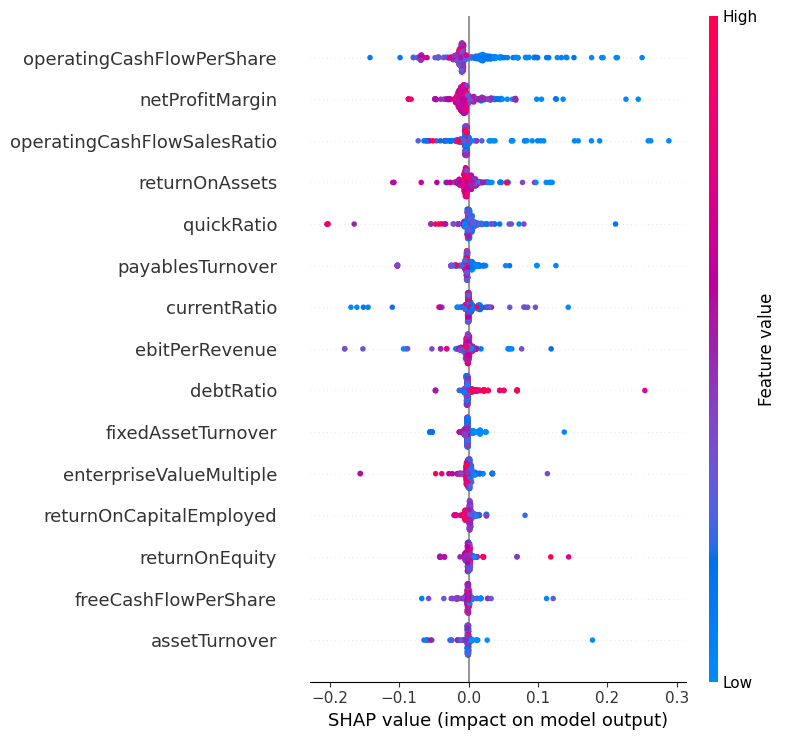

In [28]:
selected_class_name = best_model.classes_[0]
selected_class_index = list(best_model.classes_).index(selected_class_name)

selected_class_shap_values = get_class_shap_values(
    shap_values,
    selected_class_index
)

print("Selected class:", selected_class_name)

shap.summary_plot(
    selected_class_shap_values,
    X_test_shap,
    max_display=15
)

### 17.5 Explain one company prediction

This explains the same sample company used above.

Positive SHAP value:
- Pushes the model toward the selected predicted class.

Negative SHAP value:
- Pushes the model away from the selected predicted class.

In [29]:
# Change this number to explain another row from the test set.
sample_row_position = 0

sample_company = X_test.iloc[[sample_row_position]].copy()
sample_company_processed = X_test_shap.iloc[[sample_row_position]].copy()

predicted_class = best_model.predict(sample_company)[0]
predicted_class_index = list(best_model.classes_).index(predicted_class)

original_row_index = X_test.index[sample_row_position]

print("Test set row position:", sample_row_position)
print("Original dataset row index:", original_row_index)
print("Predicted RatingGroup:", predicted_class)

context_cols = [
    col for col in ["Name", "Symbol", "Sector", "Rating", "RatingGroup"]
    if col in df.columns
]

print("\nOriginal company details:")
display(df.loc[[original_row_index], context_cols])

sample_shap_values = explainer.shap_values(
    sample_company_processed,
    check_additivity=False
)

sample_class_shap_values = get_class_shap_values(
    sample_shap_values,
    predicted_class_index
)

local_shap_df = pd.DataFrame({
    "Feature": shap_feature_names,
    "Feature Value": sample_company_processed.iloc[0].values,
    "SHAP Value": sample_class_shap_values[0]
})

local_shap_df["Abs SHAP Value"] = local_shap_df["SHAP Value"].abs()
local_shap_df["Effect"] = np.where(
    local_shap_df["SHAP Value"] > 0,
    "Pushes toward predicted class",
    "Pushes away from predicted class"
)

top_local_shap = (
    local_shap_df
    .sort_values("Abs SHAP Value", ascending=False)
    .head(15)
)

display(top_local_shap)

Test set row position: 0
Original dataset row index: 1462
Predicted RatingGroup: Speculative

Original company details:


,Name,Symbol,Sector,Rating,RatingGroup
1462,EPR Properties,EPR,Consumer Services,BBB,Investment-Low


,Feature,Feature Value,SHAP Value,Abs SHAP Value,Effect
0,currentRatio,0.190268,0.368144,0.368144,Pushes toward predicted class
23,operatingCashFlowSalesRatio,0.661398,0.081671,0.081671,Pushes toward predicted class
34,Sector_Public Utilities,0.000000,0.078104,0.078104,Pushes toward predicted class
6,grossProfitMargin,0.944342,0.077823,0.077823,Pushes toward predicted class
22,operatingCashFlowPerShare,4.789638,0.071905,0.071905,Pushes toward predicted class
8,returnOnAssets,0.046127,-0.046272,0.046272,Pushes away from predicted class
9,returnOnCapitalEmployed,0.043772,0.037405,0.037405,Pushes toward predicted class
1,quickRatio,-0.027959,-0.034648,0.034648,Pushes away from predicted class
11,assetTurnover,0.099832,0.019798,0.019798,Pushes toward predicted class
4,netProfitMargin,0.462053,-0.014379,0.014379,Pushes away from predicted class


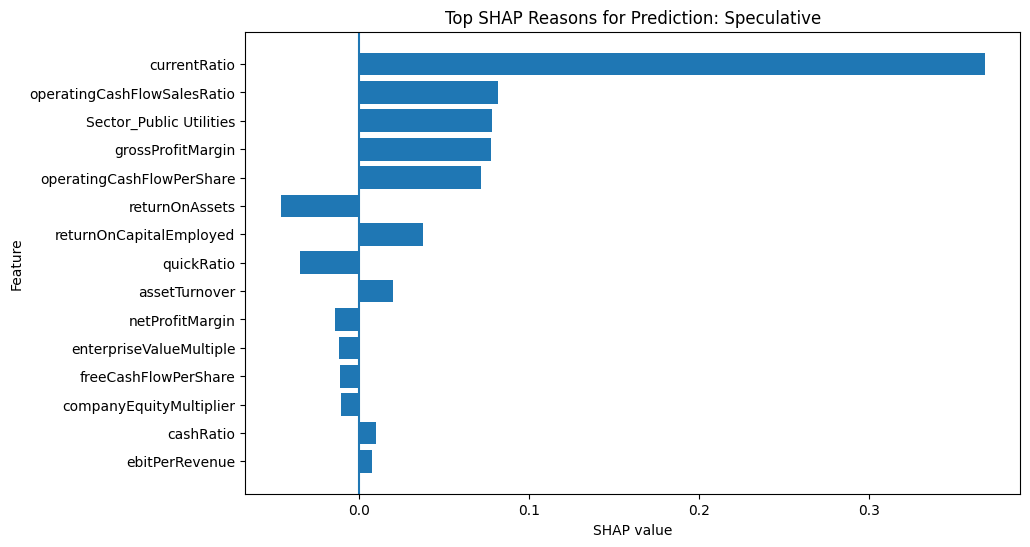

In [30]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_local_shap["Feature"][::-1],
    top_local_shap["SHAP Value"][::-1]
)
plt.title(f"Top SHAP Reasons for Prediction: {predicted_class}")
plt.xlabel("SHAP value")
plt.ylabel("Feature")
plt.axvline(0)
plt.show()

### 17.6 SHAP waterfall plot

This plot explains one prediction step by step.

It starts from the model baseline value.

Then it adds feature effects until it reaches the prediction score for the selected class.

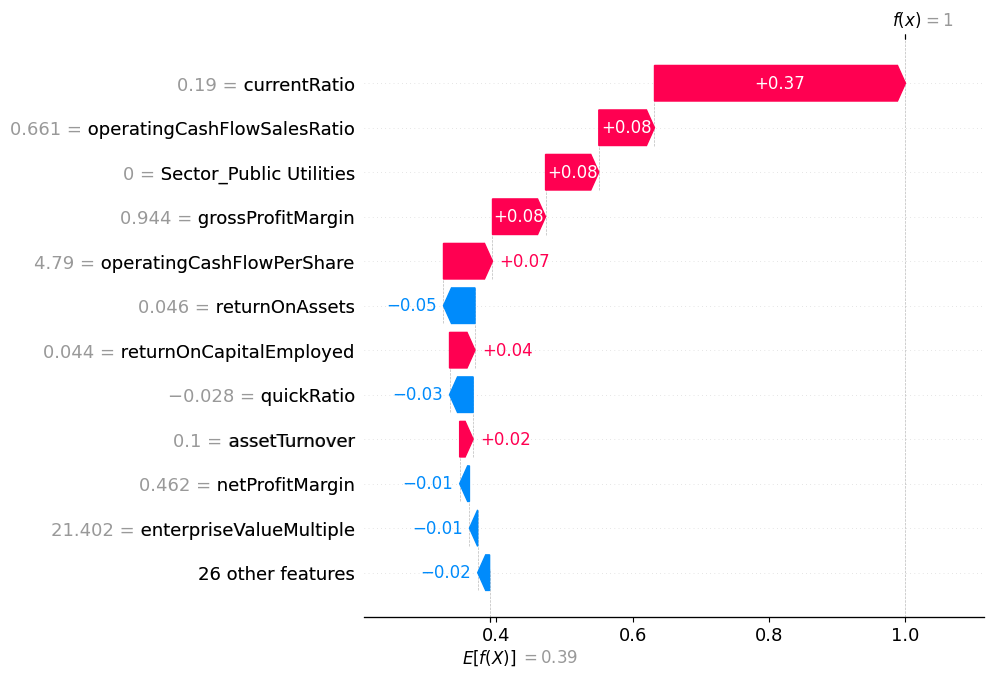

In [31]:
expected_value = explainer.expected_value

if isinstance(expected_value, list) or isinstance(expected_value, np.ndarray):
    base_value = expected_value[predicted_class_index]
else:
    base_value = expected_value

waterfall_explanation = shap.Explanation(
    values=sample_class_shap_values[0],
    base_values=base_value,
    data=sample_company_processed.iloc[0].values,
    feature_names=shap_feature_names
)

shap.plots.waterfall(
    waterfall_explanation,
    max_display=12
)

### 17.7 Simple SHAP explanation sentence

Use this sentence style in your report or presentation.

In [32]:
top_positive = (
    local_shap_df[local_shap_df["SHAP Value"] > 0]
    .sort_values("SHAP Value", ascending=False)
    .head(3)
)

top_negative = (
    local_shap_df[local_shap_df["SHAP Value"] < 0]
    .sort_values("SHAP Value", ascending=True)
    .head(3)
)

print("Presentation explanation:")
print(
    f"The model predicted this company as {predicted_class}. "
    "The strongest features pushing the prediction toward this class were "
    + ", ".join(top_positive["Feature"].tolist())
    + ". The strongest features pushing away from this class were "
    + ", ".join(top_negative["Feature"].tolist())
    + "."
)

Presentation explanation:
The model predicted this company as Speculative. The strongest features pushing the prediction toward this class were currentRatio, operatingCashFlowSalesRatio, Sector_Public Utilities. The strongest features pushing away from this class were returnOnAssets, quickRatio, netProfitMargin.


## 18. Save the trained model

This creates a `.joblib` file.

Your future website backend could load this file and use it to predict risk after a company submits financial data.


In [33]:
MODEL_PATH = "decision_tree_credit_risk_model.joblib"

joblib.dump(best_model, MODEL_PATH)

print("Model saved as:", MODEL_PATH)

Model saved as: decision_tree_credit_risk_model.joblib


## 19. Final write-up template

Use this for your report or presentation.

### What the model does

This Decision Tree model predicts a company credit risk group using financial ratios from the corporate rating dataset. Instead of predicting the raw rating, the ratings were grouped into four classes: `Investment-High`, `Investment-Low`, `Speculative`, and `High-Risk`. This makes the target more suitable because some original ratings had too few records.

### Why RatingGroup is used

The original rating column has many classes, and some classes have too little data. For example, the lowest ratings have very few records. If the model uses the raw rating directly, it may learn unstable patterns. Grouping the ratings gives the model more examples per class and makes the result easier to explain from a credit risk point of view.

### Why some columns were removed

Columns such as company name, symbol, rating agency name, and date were removed because they are not direct financial ratio indicators. Keeping them may cause the model to memorise company identity instead of learning credit risk behaviour. The original `Rating` column was also removed because it is directly linked to the answer.

### How the model was evaluated

The model was tested using accuracy, weighted F1-score, classification report, and confusion matrix. Accuracy shows the overall percentage of correct predictions. F1-score is important because the classes are imbalanced. The confusion matrix shows which risk groups the model predicts correctly and which groups it confuses.

### How the model is explained

The Decision Tree is explainable because it makes decisions using split rules. Feature importance and permutation importance were used to identify which financial ratios affected the model most. These outputs support the XAI requirement because they explain why the model arrived at a prediction.
